# Feasibility-Aware Bayesian Optimization Comparison

### Manual Baseline vs Constrained Random Search vs Penalty-based Constrained BO vs Feasibility-aware BO

This notebook is an experimental methodology comparison branch. It keeps the current main story intact and adds a side-by-side check of whether explicit feasibility modeling improves constrained PID gain search under the same v1 motor/reference/simulation conditions.

## Section 0 — Source of Truth

Before adding this branch experiment, the current main files were used as the source of truth:

- `src/optimization/pid_optimization.py`
- `src/optimization/cost_function.py`
- `src/simulation/baseline_tuning.py`
- `experiments/02_pid_baseline_tuning.ipynb`
- `experiments/03_pid_optimization.ipynb`
- `docs/project_plan.md`
- `docs/experiments/optimization_plan.md`
- `docs/experiments/performance_comparison.md`
- current `results/tables/` and `results/figures/` artifacts

The existing penalty-based constrained BO remains a baseline method: infeasible candidates receive `objective = 1e6`, and one GP learns that penalized scalar objective with EI acquisition.

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib
if not hasattr(sys, 'ps1'):
    matplotlib.use('Agg')
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'experiments':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RESULT_TABLE_DIR = ROOT / 'results' / 'tables'
RESULT_FIGURE_DIR = ROOT / 'results' / 'figures'
RESULT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

ENV = {
    'python': sys.version.split()[0],
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'matplotlib': matplotlib.__version__,
}
try:
    import sklearn
    ENV['sklearn'] = sklearn.__version__
except Exception:
    ENV['sklearn'] = None
try:
    import scipy
    ENV['scipy'] = scipy.__version__
except Exception:
    ENV['scipy'] = None

ENV

/Users/seong-uuimac/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/js/s5xbjpb56mn1ysk430xc81w40000gn/T/matplotlib-i6dulama because there was an issue with the default path (/Users/seong-uuimac/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories


Matplotlib is building the font cache; this may take a moment.


{'python': '3.13.9',
 'numpy': '2.3.5',
 'pandas': '2.3.3',
 'matplotlib': '3.10.6',
 'sklearn': '1.7.2',
 'scipy': '1.16.3'}

## Section 1 — Imports and Fixed Conditions

All optimizer methods use the same search bounds, seed, trial budget, motor plant, reference, voltage limit, and simulation settings.

In [2]:
from src.controller.pid import PIDGains
from src.motor.dc_motor import nominal_dc_motor_params
from src.optimization.cost_function import V1_CONSTRAINTS, compute_cost, is_feasible_v1, v1_constraint_checks
from src.optimization.pid_optimization import (
    PIDOptimizationConfig,
    constrained_bayesian_optimization_pid,
    constrained_random_search_pid,
    feasibility_aware_bayesian_optimization_pid,
)
from src.simulation.pid_simulation import reference_from_reachable_speed, simulate_pid

params = nominal_dc_motor_params()
V_MAX = 12.0
OMEGA_REF = round(reference_from_reachable_speed(params, V_MAX, fraction=0.5), 2)
SIMULATION_TIME = 10.0
DT = 0.001
LOAD_TORQUE = 0.0
RANDOM_SEED = 42
N_TRIALS = 80
N_INITIAL = 8
ACQUISITION_POOL_SIZE = 1200

GAIN_BOUNDS = {
    'K_p': (0.20, 1.50),
    'K_i': (0.50, 4.00),
    'K_d': (0.00, 0.01),
}

config = PIDOptimizationConfig(
    omega_ref=OMEGA_REF,
    V_max=V_MAX,
    simulation_time=SIMULATION_TIME,
    dt=DT,
    load_torque=LOAD_TORQUE,
)

conditions = pd.DataFrame([
    {'item': 'omega_ref', 'value': OMEGA_REF},
    {'item': 'V_max', 'value': V_MAX},
    {'item': 'simulation_time', 'value': SIMULATION_TIME},
    {'item': 'dt', 'value': DT},
    {'item': 'load_torque', 'value': LOAD_TORQUE},
    {'item': 'random_seed', 'value': RANDOM_SEED},
    {'item': 'trial_budget_each_optimizer', 'value': N_TRIALS},
    {'item': 'n_initial_bo', 'value': N_INITIAL},
    {'item': 'acquisition_pool_size', 'value': ACQUISITION_POOL_SIZE},
])
display(conditions)
GAIN_BOUNDS

,item,value
0,omega_ref,12.600
1,V_max,12.000
2,simulation_time,10.000
3,dt,0.001
4,load_torque,0.000
5,random_seed,42.000
6,trial_budget_each_optimizer,80.000
7,n_initial_bo,8.000
8,acquisition_pool_size,1200.000


{'K_p': (0.2, 1.5), 'K_i': (0.5, 4.0), 'K_d': (0.0, 0.01)}

## Section 2 — Method Definitions

The comparison uses the same v1 constraints as the existing constrained optimization workflow.

- **Random Search** samples candidates uniformly and selects the lowest raw `J` among feasible candidates.
- **Penalty-based Constrained BO** gives infeasible candidates `objective = 1e6`; one GP learns the penalized scalar objective and EI selects the next candidate.
- **Feasibility-aware BO** fits one objective GP on valid raw unpenalized `J`, plus separate GP regression models for each continuous constraint violation `g_i(x)`. It uses `CEI(x) = EI(x) * P_feasible(x)`, where `P_feasible = product_i P(g_i(x) <= 0)`. The product is an independence approximation across constraint models.

Constraint transforms:

```text
g_overshoot = overshoot - 0.10
g_sse = steady_state_error - 0.02
g_settling = settling_time - 2.0
g_saturation = saturation_fraction - 0.05
```

Invalid/non-finite candidates are excluded from the objective GP target and are mapped to finite positive constraint violations for the constraint GPs. Final selection always uses actually simulated `feasible=True` candidates and raw `J`.

In [3]:
constraints = pd.DataFrame([
    {'constraint': 'overshoot', 'limit': '<= 10%', 'model_target': 'overshoot - 0.10'},
    {'constraint': 'steady_state_error', 'limit': '<= 2%', 'model_target': 'steady_state_error - 0.02'},
    {'constraint': 'settling_time', 'limit': '<= 2.0 s', 'model_target': 'settling_time - 2.0'},
    {'constraint': 'saturation_fraction', 'limit': '< 5%', 'model_target': 'saturation_fraction - 0.05'},
    {'constraint': 'stable/valid', 'limit': 'finite valid response', 'model_target': 'safety handling'},
])
display(constraints)

,constraint,limit,model_target
0,overshoot,<= 10%,overshoot - 0.10
1,steady_state_error,<= 2%,steady_state_error - 0.02
2,settling_time,<= 2.0 s,settling_time - 2.0
3,saturation_fraction,< 5%,saturation_fraction - 0.05
4,stable/valid,finite valid response,safety handling


## Section 3 — Manual Baseline Load

In [4]:
BASELINE_FILE = RESULT_TABLE_DIR / 'baseline_pid_tuning_record.json'
if BASELINE_FILE.exists():
    baseline_source_record = json.loads(BASELINE_FILE.read_text(encoding='utf-8'))
else:
    baseline_source_record = {
        'K_p_baseline': 0.8,
        'K_i_baseline': 2.0,
        'K_d_baseline': 0.002,
        'note': 'Fallback fixed baseline from docs/experiments/baseline_pid_tuning.md',
    }

baseline_gains = PIDGains(
    K_p=float(baseline_source_record['K_p_baseline']),
    K_i=float(baseline_source_record['K_i_baseline']),
    K_d=float(baseline_source_record['K_d_baseline']),
)

baseline_result = simulate_pid(
    params,
    gains=baseline_gains,
    omega_ref=OMEGA_REF,
    V_max=V_MAX,
    simulation_time=SIMULATION_TIME,
    dt=DT,
    load_torque=LOAD_TORQUE,
)
baseline_cost = compute_cost(baseline_result, omega_ref=OMEGA_REF, V_max=V_MAX)
baseline_feasible = is_feasible_v1(baseline_cost)
assert baseline_feasible, 'Manual baseline must satisfy v1 constraints.'

baseline_summary = pd.DataFrame([{
    'Method': 'Manual Baseline',
    'K_p': baseline_gains.K_p,
    'K_i': baseline_gains.K_i,
    'K_d': baseline_gains.K_d,
    'total_J': baseline_cost['total'],
    'tracking_cost': baseline_cost['tracking'],
    'overshoot_cost': baseline_cost['overshoot_cost'],
    'control_effort': baseline_cost['control'],
    'overshoot_percent': baseline_cost['overshoot_percent'],
    'settling_time': baseline_cost['settling_time'],
    'steady_state_error_percent': baseline_cost['steady_state_error_percent'],
    'voltage_max_abs': baseline_cost['voltage_max_abs'],
    'saturation_percent': baseline_cost['saturation_percent'],
    'omega_final': baseline_cost['omega_final'],
    'feasible': baseline_feasible,
    'evaluations': 0,
    'trial_budget': 'fixed benchmark',
}])
display(baseline_summary.T.rename(columns={0: 'value'}))

,value
Method,Manual Baseline
K_p,0.8
K_i,2.0
K_d,0.002
total_J,0.038177
tracking_cost,0.000114
overshoot_cost,0.0
control_effort,0.254054
overshoot_percent,0.0
settling_time,1.322


## Section 4 — Run the Three Optimizers

In [5]:
def history_frame(records, method):
    frame = pd.DataFrame(records).copy()
    frame.insert(0, 'Method', method)
    best_so_far = []
    current = np.inf
    for _, row in frame.iterrows():
        if bool(row.get('feasible', False)) and np.isfinite(row.get('total', np.nan)):
            current = min(current, float(row['total']))
        best_so_far.append(current if np.isfinite(current) else np.nan)
    frame['feasible_best_so_far'] = best_so_far
    frame['feasible_count_so_far'] = frame['feasible'].astype(bool).cumsum()
    return frame

random_records, random_best = constrained_random_search_pid(
    motor_params=params,
    bounds=GAIN_BOUNDS,
    n_trials=N_TRIALS,
    config=config,
    seed=RANDOM_SEED,
)

penalty_records, penalty_best = constrained_bayesian_optimization_pid(
    motor_params=params,
    bounds=GAIN_BOUNDS,
    n_trials=N_TRIALS,
    config=config,
    seed=RANDOM_SEED,
    n_initial=N_INITIAL,
    acquisition_pool_size=ACQUISITION_POOL_SIZE,
)

feasibility_records, feasibility_best = feasibility_aware_bayesian_optimization_pid(
    motor_params=params,
    bounds=GAIN_BOUNDS,
    n_trials=N_TRIALS,
    config=config,
    seed=RANDOM_SEED,
    n_initial=N_INITIAL,
    acquisition_pool_size=ACQUISITION_POOL_SIZE,
)

assert random_best['feasible'], 'Random Search best candidate must be feasible.'
assert penalty_best['feasible'], 'Penalty BO best candidate must be feasible.'
assert feasibility_best['feasible'], 'Feasibility-aware BO best candidate must be feasible.'
assert all(not r['used_penalty_in_objective_model'] for r in feasibility_records), 'Feasibility-aware BO must not train the objective GP on penalty targets.'
assert all(r['objective_model_target'] != config.penalty_cost for r in feasibility_records if np.isfinite(r['objective_model_target'])), 'Penalty cost leaked into feasibility-aware objective targets.'

random_history = history_frame(random_records, 'Constrained Random Search')
penalty_history = history_frame(penalty_records, 'Penalty-based Constrained BO')
feasibility_history = history_frame(feasibility_records, 'Feasibility-aware BO')

optimizer_summary = pd.DataFrame([
    {'Method': 'Constrained Random Search', 'feasible_count': int(random_history['feasible'].sum()), 'feasible_ratio': float(random_history['feasible'].mean()), 'best_total_J': random_best['total']},
    {'Method': 'Penalty-based Constrained BO', 'feasible_count': int(penalty_history['feasible'].sum()), 'feasible_ratio': float(penalty_history['feasible'].mean()), 'best_total_J': penalty_best['total']},
    {'Method': 'Feasibility-aware BO', 'feasible_count': int(feasibility_history['feasible'].sum()), 'feasible_ratio': float(feasibility_history['feasible'].mean()), 'best_total_J': feasibility_best['total']},
])
display(optimizer_summary)

,Method,feasible_count,feasible_ratio,best_total_J
0,Constrained Random Search,45,0.5625,0.036768
1,Penalty-based Constrained BO,51,0.6375,0.036702
2,Feasibility-aware BO,10,0.1250,0.036610


## Section 5 — 4-Way Final Comparison

In [6]:
def row_from_best(method, record, evaluations, trial_budget=N_TRIALS):
    return {
        'Method': method,
        'K_p': float(record['K_p']),
        'K_i': float(record['K_i']),
        'K_d': float(record['K_d']),
        'total_J': float(record['total']),
        'tracking_cost': float(record['tracking']),
        'overshoot_cost': float(record['overshoot_cost']),
        'control_effort': float(record['control']),
        'overshoot_percent': float(record['overshoot_percent']),
        'settling_time': float(record['settling_time']),
        'steady_state_error_percent': float(record['steady_state_error_percent']),
        'voltage_max_abs': float(record['voltage_max_abs']),
        'saturation_percent': float(record['saturation_percent']),
        'omega_final': float(record['omega_final']),
        'feasible': bool(record['feasible']),
        'evaluations': evaluations,
        'trial_budget': trial_budget,
    }

comparison = pd.concat([
    baseline_summary,
    pd.DataFrame([
        row_from_best('Constrained Random Search', random_best, len(random_records)),
        row_from_best('Penalty-based Constrained BO', penalty_best, len(penalty_records)),
        row_from_best('Feasibility-aware BO', feasibility_best, len(feasibility_records)),
    ]),
], ignore_index=True)

baseline_j = float(comparison.loc[comparison['Method'] == 'Manual Baseline', 'total_J'].iloc[0])
comparison['J_improvement_vs_baseline_percent'] = (baseline_j - comparison['total_J']) / baseline_j * 100.0
comparison = comparison[[
    'Method', 'K_p', 'K_i', 'K_d', 'total_J', 'tracking_cost', 'overshoot_cost',
    'control_effort', 'overshoot_percent', 'settling_time', 'steady_state_error_percent',
    'voltage_max_abs', 'saturation_percent', 'omega_final', 'feasible', 'evaluations',
    'trial_budget', 'J_improvement_vs_baseline_percent',
]]

assert comparison['feasible'].all(), 'All four reported controllers must satisfy v1 constraints.'
display(comparison)

,Method,K_p,K_i,K_d,total_J,tracking_cost,overshoot_cost,control_effort,overshoot_percent,settling_time,steady_state_error_percent,voltage_max_abs,saturation_percent,omega_final,feasible,evaluations,trial_budget,J_improvement_vs_baseline_percent
0,Manual Baseline,0.800000,2.000000,0.002000,0.038177,0.000114,0.000000e+00,0.254054,0.000000,1.322,2.158821e-07,10.242803,0.0,12.6,True,0,fixed benchmark,0.000000
1,Constrained Random Search,0.256945,1.040013,0.006830,0.036768,0.000548,8.410873e-11,0.242923,0.000917,1.550,4.536054e-10,6.000142,0.0,12.6,True,80,80,3.690676
2,Penalty-based Constrained BO,0.215097,0.996516,0.000855,0.036702,0.000611,7.499755e-09,0.242238,0.008660,1.547,4.709601e-10,6.001635,0.0,12.6,True,80,80,3.861902
3,Feasibility-aware BO,0.225860,0.963391,0.005592,0.036610,0.000644,1.154713e-10,0.241487,0.001075,1.649,1.267670e-09,6.000132,0.0,12.6,True,80,80,4.104490


## Section 6 — Response and Control Plots

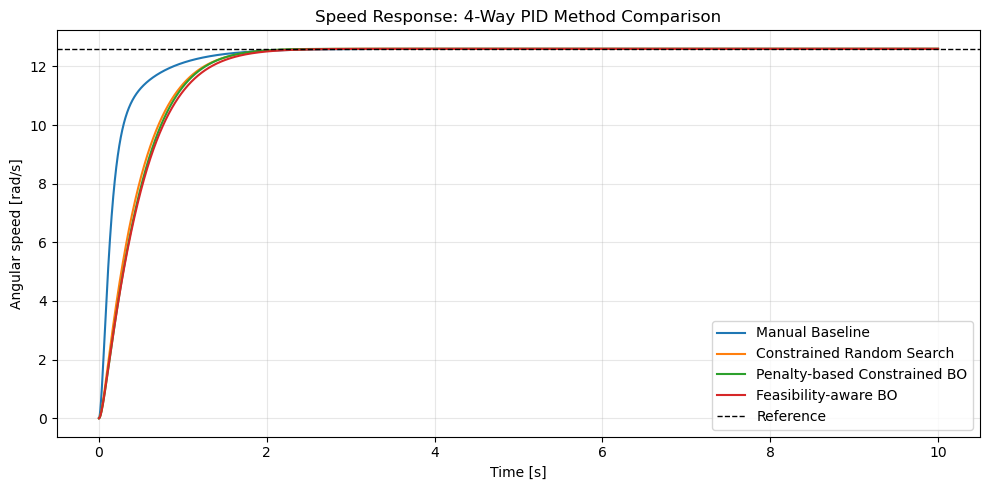

In [7]:
controller_gains = {
    'Manual Baseline': baseline_gains,
    'Constrained Random Search': PIDGains(random_best['K_p'], random_best['K_i'], random_best['K_d']),
    'Penalty-based Constrained BO': PIDGains(penalty_best['K_p'], penalty_best['K_i'], penalty_best['K_d']),
    'Feasibility-aware BO': PIDGains(feasibility_best['K_p'], feasibility_best['K_i'], feasibility_best['K_d']),
}

responses = {}
for method, gains in controller_gains.items():
    responses[method] = simulate_pid(
        params,
        gains=gains,
        omega_ref=OMEGA_REF,
        V_max=V_MAX,
        simulation_time=SIMULATION_TIME,
        dt=DT,
        load_torque=LOAD_TORQUE,
    )

fig, ax = plt.subplots(figsize=(10, 5))
for method, result in responses.items():
    ax.plot(result['time'], result['omega'], label=method)
ax.axhline(OMEGA_REF, linestyle='--', color='black', linewidth=1, label='Reference')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Angular speed [rad/s]')
ax.set_title('Speed Response: 4-Way PID Method Comparison')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(RESULT_FIGURE_DIR / 'feasibility_aware_bo_speed_response.png', dpi=160)
plt.show()

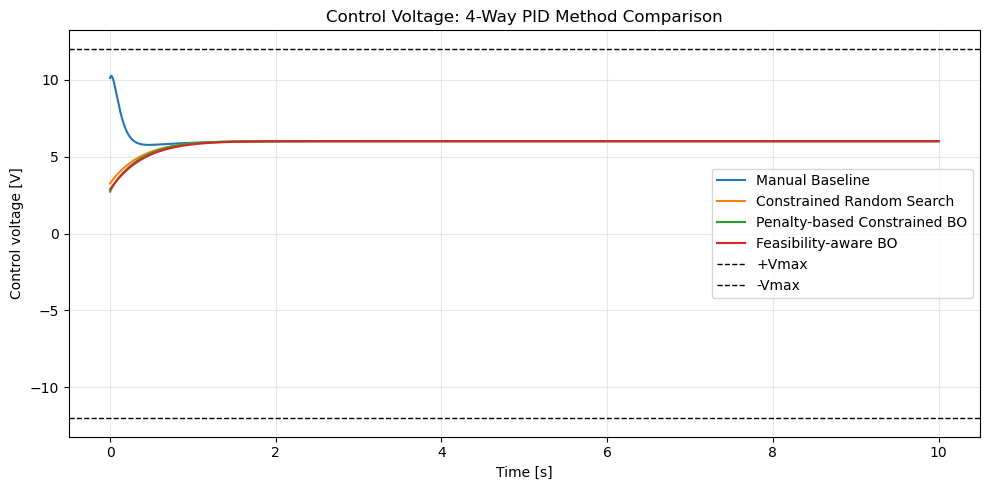

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
for method, result in responses.items():
    ax.plot(result['time'], result['voltage'], label=method)
ax.axhline(V_MAX, linestyle='--', color='black', linewidth=1, label='+Vmax')
ax.axhline(-V_MAX, linestyle='--', color='black', linewidth=1, label='-Vmax')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Control voltage [V]')
ax.set_title('Control Voltage: 4-Way PID Method Comparison')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(RESULT_FIGURE_DIR / 'feasibility_aware_bo_control_voltage.png', dpi=160)
plt.show()

## Section 7 — Optimizer Convergence and Feasibility Counts

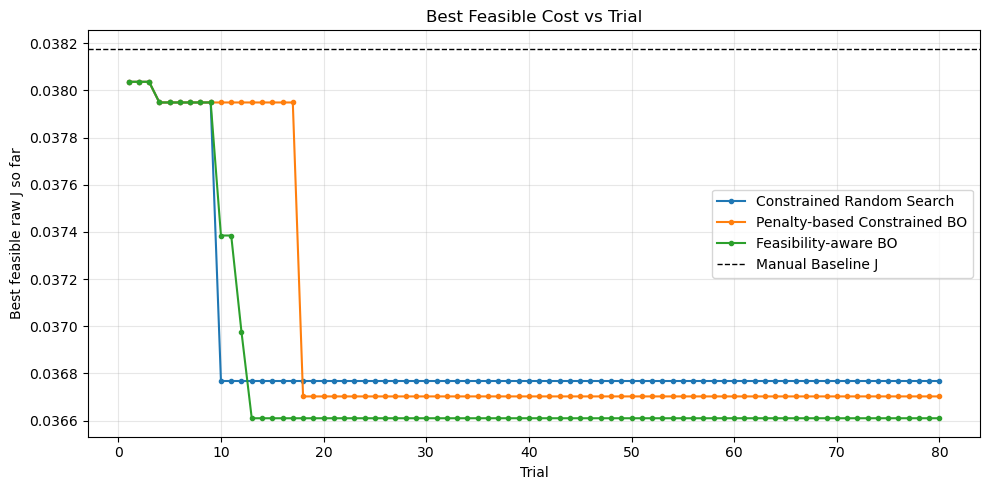

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
for frame, label in [
    (random_history, 'Constrained Random Search'),
    (penalty_history, 'Penalty-based Constrained BO'),
    (feasibility_history, 'Feasibility-aware BO'),
]:
    ax.plot(frame['trial'], frame['feasible_best_so_far'], marker='o', markersize=3, label=label)
ax.axhline(baseline_j, linestyle='--', color='black', linewidth=1, label='Manual Baseline J')
ax.set_xlabel('Trial')
ax.set_ylabel('Best feasible raw J so far')
ax.set_title('Best Feasible Cost vs Trial')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(RESULT_FIGURE_DIR / 'feasibility_aware_bo_convergence.png', dpi=160)
plt.show()

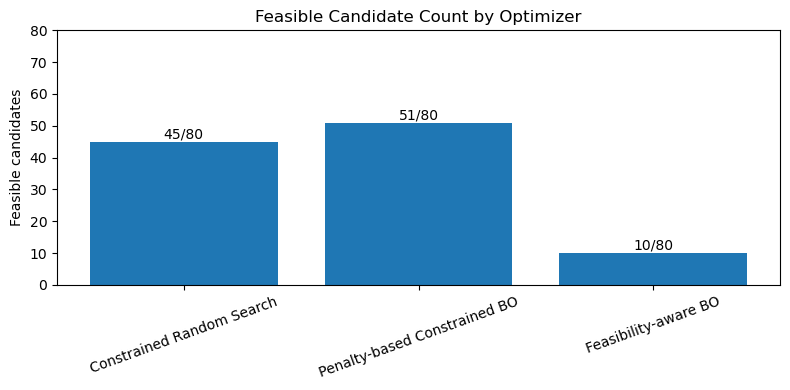

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(optimizer_summary['Method'], optimizer_summary['feasible_count'])
ax.set_ylabel('Feasible candidates')
ax.set_title('Feasible Candidate Count by Optimizer')
ax.set_ylim(0, N_TRIALS)
ax.tick_params(axis='x', rotation=20)
for idx, value in enumerate(optimizer_summary['feasible_count']):
    ax.text(idx, value + 1, f'{value}/{N_TRIALS}', ha='center')
fig.tight_layout()
fig.savefig(RESULT_FIGURE_DIR / 'feasibility_aware_bo_feasible_counts.png', dpi=160)
plt.show()

## Section 8 — Analysis

In [11]:
best_optimizer_method = optimizer_summary.sort_values('best_total_J').iloc[0]['Method']
most_feasible_method = optimizer_summary.sort_values('feasible_count', ascending=False).iloc[0]['Method']
penalty_j = float(optimizer_summary.loc[optimizer_summary['Method'] == 'Penalty-based Constrained BO', 'best_total_J'].iloc[0])
feasibility_j = float(optimizer_summary.loc[optimizer_summary['Method'] == 'Feasibility-aware BO', 'best_total_J'].iloc[0])
random_j = float(optimizer_summary.loc[optimizer_summary['Method'] == 'Constrained Random Search', 'best_total_J'].iloc[0])

analysis = {
    'best_final_J_method': best_optimizer_method,
    'most_feasible_candidates_method': most_feasible_method,
    'feasibility_aware_minus_penalty_J': feasibility_j - penalty_j,
    'feasibility_aware_minus_random_J': feasibility_j - random_j,
    'interpretation': (
        'Feasibility-aware BO explicitly models constraint satisfaction and selects candidates with CEI. '
        'Under this fixed 80-trial seed, compare final J, feasible counts, and best-feasible trajectory rather than assuming one method universally dominates.'
    ),
    'limitations': [
        'P_feasible uses a product of independent GP-predicted constraint probabilities.',
        'Each constraint GP is a regression surrogate over deterministic simulated metrics.',
        'The trial budget is small, so conclusions are seed- and budget-dependent.',
        'Invalid simulations are kept out of the objective GP and represented as finite positive constraint violations.',
    ],
}
analysis

{'best_final_J_method': 'Feasibility-aware BO',
 'most_feasible_candidates_method': 'Penalty-based Constrained BO',
 'feasibility_aware_minus_penalty_J': -9.261163041309611e-05,
 'feasibility_aware_minus_random_J': -0.0001579797307895009,
 'interpretation': 'Feasibility-aware BO explicitly models constraint satisfaction and selects candidates with CEI. Under this fixed 80-trial seed, compare final J, feasible counts, and best-feasible trajectory rather than assuming one method universally dominates.',
 'limitations': ['P_feasible uses a product of independent GP-predicted constraint probabilities.',
  'Each constraint GP is a regression surrogate over deterministic simulated metrics.',
  'The trial budget is small, so conclusions are seed- and budget-dependent.',
  'Invalid simulations are kept out of the objective GP and represented as finite positive constraint violations.']}

## Section 9 — Save Results

In [12]:
comparison.to_csv(RESULT_TABLE_DIR / 'feasibility_aware_bo_comparison.csv', index=False)
random_history.to_csv(RESULT_TABLE_DIR / 'feasibility_aware_bo_random_search_history.csv', index=False)
penalty_history.to_csv(RESULT_TABLE_DIR / 'feasibility_aware_bo_penalty_bo_history.csv', index=False)
feasibility_history.to_csv(RESULT_TABLE_DIR / 'feasibility_aware_bo_history.csv', index=False)
optimizer_summary.to_csv(RESULT_TABLE_DIR / 'feasibility_aware_bo_optimizer_summary.csv', index=False)

summary = {
    'branch_experiment': 'feature/feasibility-aware-bo',
    'conditions': {
        'omega_ref': OMEGA_REF,
        'V_max': V_MAX,
        'simulation_time': SIMULATION_TIME,
        'dt': DT,
        'load_torque': LOAD_TORQUE,
        'random_seed': RANDOM_SEED,
        'trial_budget_each_optimizer': N_TRIALS,
        'n_initial_bo': N_INITIAL,
        'acquisition_pool_size': ACQUISITION_POOL_SIZE,
        'gain_bounds': GAIN_BOUNDS,
    },
    'method_definitions': {
        'Penalty-based Constrained BO': 'infeasible -> objective=1e6, single GP on penalized objective, EI acquisition',
        'Feasibility-aware BO': 'objective GP on raw valid J plus separate constraint GPs, CEI=EI*P(feasible)',
        'Constrained Random Search': 'uniform sampling with explicit feasible-candidate final selection',
    },
    'comparison': comparison.to_dict(orient='records'),
    'optimizer_summary': optimizer_summary.to_dict(orient='records'),
    'analysis': analysis,
    'environment': ENV,
}
with open(RESULT_TABLE_DIR / 'feasibility_aware_bo_comparison.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print('Saved:')
print(RESULT_TABLE_DIR / 'feasibility_aware_bo_comparison.csv')
print(RESULT_TABLE_DIR / 'feasibility_aware_bo_comparison.json')
print(RESULT_FIGURE_DIR / 'feasibility_aware_bo_speed_response.png')
print(RESULT_FIGURE_DIR / 'feasibility_aware_bo_control_voltage.png')
print(RESULT_FIGURE_DIR / 'feasibility_aware_bo_convergence.png')
print(RESULT_FIGURE_DIR / 'feasibility_aware_bo_feasible_counts.png')

Saved:
/Users/seong-uuimac/Documents/Codex/2026-09-07/referenced-chatgpt-conversation-this-is-an/motor-control-optimization/results/tables/feasibility_aware_bo_comparison.csv
/Users/seong-uuimac/Documents/Codex/2026-09-07/referenced-chatgpt-conversation-this-is-an/motor-control-optimization/results/tables/feasibility_aware_bo_comparison.json
/Users/seong-uuimac/Documents/Codex/2026-09-07/referenced-chatgpt-conversation-this-is-an/motor-control-optimization/results/figures/feasibility_aware_bo_speed_response.png
/Users/seong-uuimac/Documents/Codex/2026-09-07/referenced-chatgpt-conversation-this-is-an/motor-control-optimization/results/figures/feasibility_aware_bo_control_voltage.png
/Users/seong-uuimac/Documents/Codex/2026-09-07/referenced-chatgpt-conversation-this-is-an/motor-control-optimization/results/figures/feasibility_aware_bo_convergence.png
/Users/seong-uuimac/Documents/Codex/2026-09-07/referenced-chatgpt-conversation-this-is-an/motor-control-optimization/results/figures/feasib

## Section 10 — Conclusion

This branch adds feasibility-aware BO as an optional methodology study. The current main story remains unchanged: penalty-based constrained BO is still preserved as the existing constrained BO baseline, and final comparison is based on actually feasible simulated candidates rather than surrogate predictions alone.